#Task 1: MCP Neuron Implementation

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AND Gate

In [ ]:
def MCP_Neurons_AND(X1, X2, T):
    assert len(X1) == len(X2)

    state_neuron = []

    # Element-wise addition and threshold check
    for i in range(len(X1)):
        s = X1[i] + X2[i]

        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Sample Usage
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2

result = MCP_Neurons_AND(X1, X2, T)
print(f"Output of AND gate: {result}")

Output of AND gate: [0, 0, 0, 1]


OR Gate

In [ ]:
def MCP_Neurons_OR(X1, X2, T):
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        s = X1[i] + X2[i]

        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Sample Usage
T = 1

result_or = MCP_Neurons_OR(X1, X2, T)
print(f"Output of OR gate: {result_or}")

Output of OR gate: [0, 1, 1, 1]


#Task 1 Answers

Q1: Limitations of MCP Neuron

- It cannot learn from data.
- We have to manually set threshold.
- It only works for simple problems.
- It cannot solve non-linear problems like XOR.
- No weight adjustment.
- Only works with binary values (0 and 1).


Q2: XOR using MCP

No, a single MCP neuron cannot solve XOR.

Reason:
XOR is not linearly separable.

We can only solve XOR using multiple neurons (multi-layer), not with a single MCP neuron.

#Task 2: Perceptron (0 vs 1)

Load Dataset

In [1]:
import pandas as pd
import numpy as np

df_0_1 = pd.read_csv("/content/mnist_0_and_1.csv")

X = df_0_1.drop(columns=["label"]).values
y = df_0_1["label"].values

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (12665, 784)
Shape of y: (12665,)


Q1: What does shape of X represent?

It shows:
- Number of images (rows)
- Number of features (columns = pixels)

Example:
If shape is (1000, 784)
→ 1000 images, each having 784 pixels


Q2: What does shape of y represent?

It shows labels for each image.
Each value is either 0 or 1.

Visualization

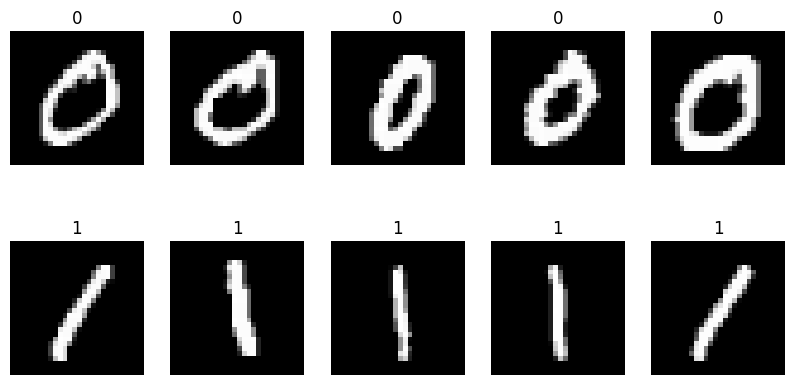

In [2]:
import matplotlib.pyplot as plt

images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("0")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("1")
    axes[1, i].axis("off")

plt.show()

Initialize

In [3]:
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 100

Qsn Answers

Q3: What does weights represent?

Each weight represents importance of a pixel in prediction.


Q4: Why initialize weights to zero?

It is a simple starting point.
Model will learn and update weights during training.

Decision Function

In [4]:
def decision_function(X, weights, bias):
    result = np.dot(X, weights) + bias
    return np.where(result >= 0, 1, 0)

Train Perceptron

In [5]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):

    for epoch in range(epochs):
        correct = 0

        for i in range(len(X)):
            output = np.dot(X[i], weights) + bias
            y_pred = 1 if output >= 0 else 0

            if y_pred == y[i]:
                correct += 1
            else:
                weights = weights + learning_rate * (y[i] - y_pred) * X[i]
                bias = bias + learning_rate * (y[i] - y_pred)

        accuracy = correct / len(X)

    return weights, bias, accuracy

Qsn Answers

Q5: Purpose of np.dot(X[i], weights) + bias?

It calculates weighted sum to make prediction.


Q6: What happens if prediction is wrong?

Weights and bias are updated to reduce error.


Q7: Why accuracy important?

It tells how well the model is performing.
For 0 vs 1, accuracy should be high.

Train Model

In [6]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("Final Accuracy:", accuracy)

Final Accuracy: 1.0


Misclassified Images

In [7]:
pred = np.dot(X, weights) + bias
y_pred = np.where(pred >= 0, 1, 0)

mis_idx = np.where(y_pred != y)[0]

if len(mis_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, mis_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"P:{y_pred[idx]} T:{y[idx]}")
        ax.axis("off")

    plt.show()
else:
    print("All images correct")

All images correct


Question Answers

Q8: What is mis_idx?

It stores indexes of wrong predictions.


Q9: If all correct?

Model is perfectly trained.

#Task 3: (3 vs 5)

Load

In [9]:
df = pd.read_csv("/content/mnist_3_and_5.csv")

X_35 = df.drop(columns=["label"]).values
y_35 = df["label"].values

Train

In [10]:
weights = np.zeros(X_35.shape[1])
bias = 0

weights, bias, acc = train_perceptron(X_35, y_35, weights, bias)

print("Accuracy:", acc)

Accuracy: 0.0


Misclassified

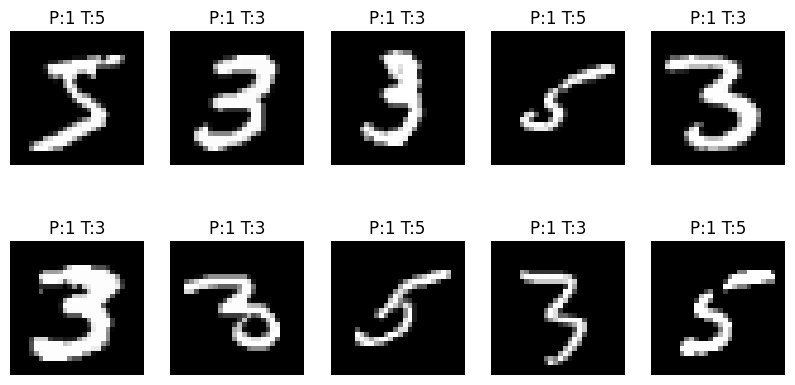

In [11]:
pred = np.dot(X_35, weights) + bias
y_pred = np.where(pred >= 0, 1, 0)

mis_idx = np.where(y_pred != y_35)[0]

if len(mis_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, mis_idx[:10]):
        ax.imshow(X_35[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"P:{y_pred[idx]} T:{y_35[idx]}")
        ax.axis("off")

    plt.show()
else:
    print("All correct")

Conclusion

3 vs 5 is harder than 0 vs 1.

Reason:
- Digits look similar
- Data is not perfectly linearly separable

So accuracy is lower.

This shows limitation of perceptron.